# 라이브러리 및 데이터셋 준비

- torch: 딥러닝 실험에서 많이 쓰이는 파이썬 라이브러리 PyTorch (Tensorflow, Keras쓰는 방법도 있지만 저는 이게 좋더라구요. 딴거 써도 됩니다!)

- torchvision: PyTorch 라이브러리랑 비슷한데 이미지 데이터 셋들 불러 올때나 데이터 전처리 할 때 씀! 

- torch.utils.data: 데이터 셋을 모델에 공급하는 방식을 정하는 DataLoader 불러 오기 위해 씀! 

- matplotlib.pyplot: 간단한 이미지 처리나 시각화 해서 보여줄 때 쓴느 라이브러리

- numpy: number python에서 유래됨. 복잡한 python에 없는 계산을 하게 해줌. 필수라서 나중에 공부하시게 될거에요!

- 외워야 되는건 아닌데 그냥 이런걸 앞으로 많이 보게 될거에요~

# MNIST 
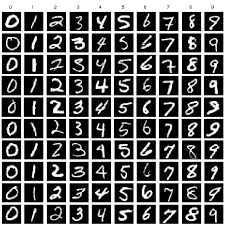

# FashionMNIST
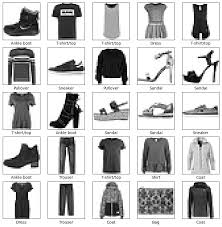


# 밑에 코드에서 `DATASET_NAME = 'MNIST'` 혹은   
# `DATASET_NAME = 'FashionMNIST'`중에 하나만 골라서 각각 실행해보세요!

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# 이거 둘 중에 하나만 골라서 밑에 다 실행 해보세요!
# 대신 둘 다 확인하자...
# 실습할 데이터셋 선택 ('MNIST' 또는 'FashionMNIST')
DATASET_NAME = 'MNIST'
# DATASET_NAME = 'FashionMNIST' 

# 하이퍼파라미터 설정
BATCH_SIZE = 64

# EPOCHS을 5보다 더 많이 하면 학습 결과가 바뀔거임 최대 20까지 추천합니다!
EPOCHS = 5
LEARNING_RATE = 0.001

# 디바이스 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"현재 사용하는 디바이스: {device}")

# 데이터 전처리 (이미지를 텐서로 변환하고 -1 ~ 1 사이로 정규화)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 데이터셋 다운로드 및 로드
if DATASET_NAME == 'MNIST':
    
    train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
else:
    train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# DataLoader 생성 (셔플 옵션을 활성화하여 다양하게 학습)
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# 시각화를 위해 테스트 로더는 셔플을 True로 설정하여 매번 다른 샘플을 볼 수 있게 합니다.
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"{DATASET_NAME} 데이터셋 로드 완료!")

ModuleNotFoundError: No module named 'torch'

In [ ]:
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.flatten = nn.Flatten() # 28x28 이미지를 784 차원의 1차원 벡터로 변환
        self.fc1 = nn.Linear(28 * 28, 128) # 은닉층
        self.relu = nn.ReLU()              # 활성화 함수
        self.fc2 = nn.Linear(128, 10)      # 출력층 (10개 클래스)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# 모델 생성 및 디바이스 이동

# SimpleNet(): SimpleNet이라는 클래스의 Object를 만든것 

# .to(device) 하는 이유는 CPU에 기본으로 모델의 object가 저장되는데 
# #CUDA(nvidia)나 MPS(apple)를 쓸 때 따로 조정하기 위해 
model = SimpleNet().to(device)

# 손실 값을 계산하는 기준을 정함 (손실함수 정의)
# 손실 값은 모델이 정답을 얼마나 잘 맞추냐와 비슷한 개념 
# 손실 값이 높을수록 많이 틀렸다는 뜻
# 손실 값을 최소화 하는 방향으로 학습해야하고 손실 값이 0과 근사하면 이 모델은 문제를 주면 정답을 100퍼센트 맞추는 모델임
# 이미지 분류에선 CrossEntropy라는 함수를 쓰는데 인터넷에 검색하면 이해하기 쉬움
criterion = nn.CrossEntropyLoss()

# 손실값을 계산하고 모델의 파라미터를 바꿀 때 어떻게, 얼마나 바꿀지 정하는 코드 
# 보통은 optimizer는 SGD 아니면 Adam을 씀 
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
print("모델 및 손실함수 정의 완료!")

모델 및 손실함수 정의 완료!


# CNN 모델 정의


꼭 읽어보세요!: https://rubber-tree.tistory.com/116

In [ ]:
# 2. CNN 모델 정의
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 10)
    
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = self.fc1(x)
        return x

model = SimpleCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print("모델 및 손실함수 정의 완료!")

# 모델 학습 코드

- 모델을 정의하고 입력값을 모델에 넣고(forward) criterion으로 손실 값을 계산해서 backpropagation(역전파)으로 모델의 가중치를 하나하나 고칠건데 이게 한 두번 고친다고 모델이 100퍼센트 정답을 맞출 수 없음!

- 따라서 이 수정하는 행위를 여러 번 해야하는데 단위가 epoch임. 천 번 반복 = 1000 epoch



In [7]:
print(f"--- {DATASET_NAME} 학습 시작 ---")
model.train() # 모델을 학습 모드로 설정

for epoch in range(EPOCHS):
    running_loss = 0.0
    for images, labels in train_loader:
        # 입력값 = images
        # 정답 = labels
        images, labels = images.to(device), labels.to(device)
        
        # backpropagation(역전파) 할 때 기울기 값이 구해지는데 매번 초기화 해줘야함
        optimizer.zero_grad()        # 기울기 초기화

        # 출력값 <== 모델(입력값) 
        outputs = model(images)      # 순전파

        # 손실 값 <== 손실함수(출력값, 정답)
        # 모델의 출력값은 예측한 값임. 이를 정답과 비교해서 손실의 정도를 계산함!
        loss = criterion(outputs, labels) # 손실 계산

        # Backpropagtion
        # 출력 값은 연산(연산(연산(연산....)))과 같은데 출력 값을 각 연산으로 미분하면 
        # 그 연산에서의 기울기를 구할 수 있음
        # 기울기가 뭐냐? 그 연산을 함으로써 일어난 변화의 크기 정도 
        # 기울기가 높으면 그만큼 영향을 많이 끼침
        # 예를 들어 손실값이 높은데 연산1의 미분 값이 높음 
        # 그러면 연산1이라는 행위가 손실을 높인것으로 판단 수정의 정도가 큼!
        loss.backward()              # 역전파 (기울기 계산)

        # 수정할 정도를 알았다면 앞서 명시했던 방법으로 가중치를 수정!
        optimizer.step()             # 가중치 업데이트
        
        running_loss += loss.item()
        
    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {running_loss/len(train_loader):.4f}")

print("--- 학습 완료 ---")

--- MNIST 학습 시작 ---
Epoch [1/5], Loss: 0.3875
Epoch [2/5], Loss: 0.2016
Epoch [3/5], Loss: 0.1469
Epoch [4/5], Loss: 0.1174
Epoch [5/5], Loss: 0.1024
--- 학습 완료 ---


# 학습된 모델 성능 검정

- 우리가 앞서 했던 내용은 학습!

- 이제는 실제로 써볼 시간 = 추론! (인공지능 모델의 추론)

- 여러 번 돌리다 보면 한 번씩 틀리게 추론하는 경우가 있음! 

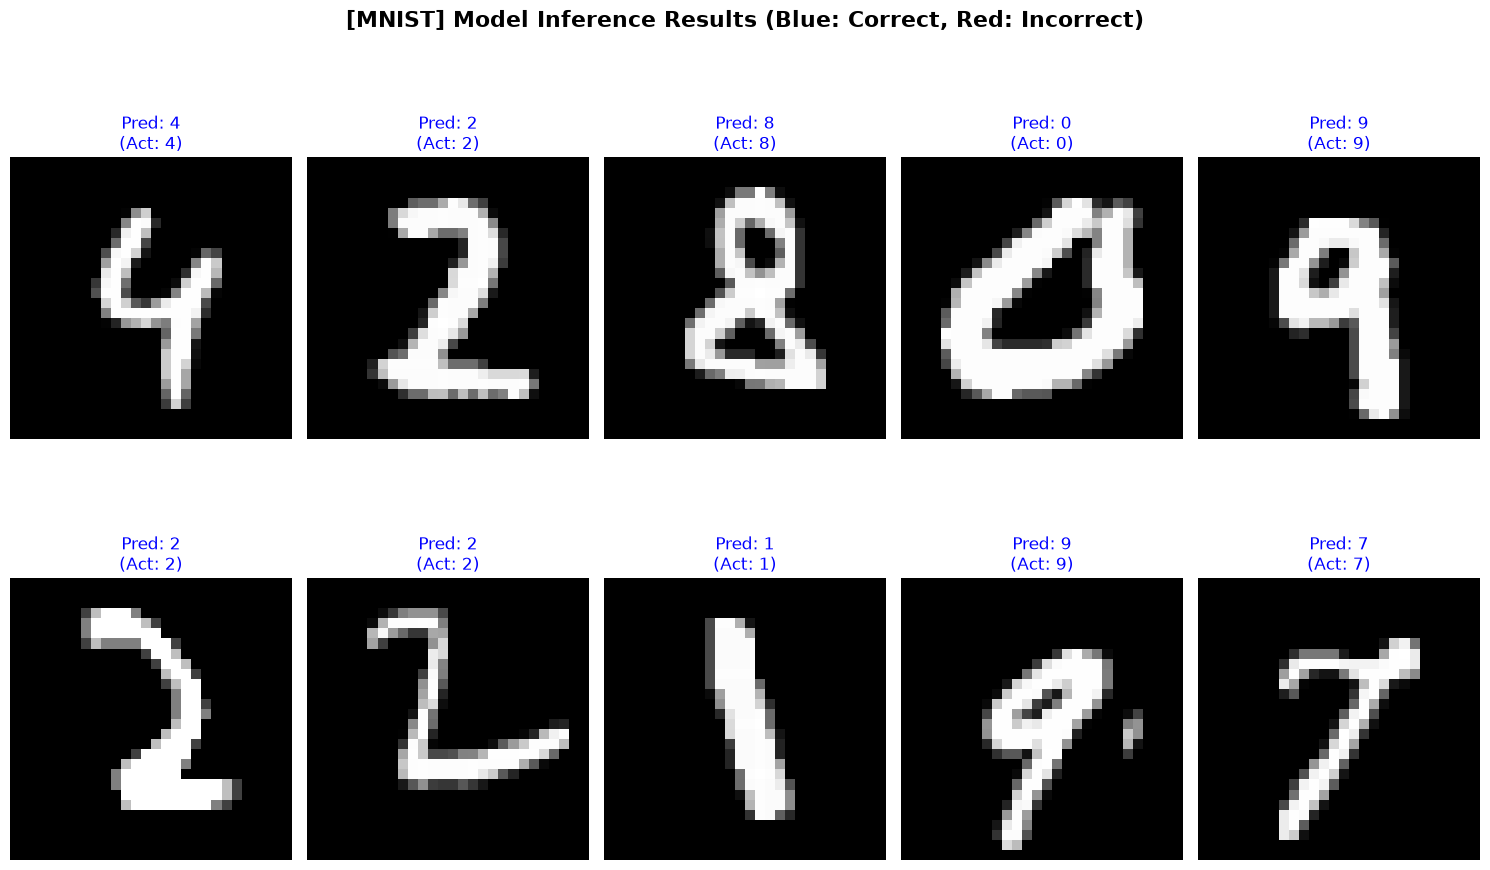

In [19]:
# FashionMNIST를 선택했을 때 텍스트 라벨을 매핑하기 위한 리스트
fashion_labels = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", 
                  "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

model.eval() # 모델을 평가 모드로 전환

# 테스트 데이터로더에서 무작위 배치 1개를 가져옵니다.
data_iter = iter(test_loader)
images, labels = next(data_iter)

# 그중 앞의 10개 데이터만 슬라이싱합니다.
sample_images = images[:10]
sample_labels = labels[:10]

# 모델에 데이터를 넣어 예측값을 계산합니다.
with torch.no_grad():
    outputs = model(sample_images.to(device))
    _, predicted = torch.max(outputs, 1) # 가장 확률이 높은 클래스 선택

# 시각화 창 설정 (2행 5열 구조)
plt.figure(figsize=(15, 10))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    
    # 텐서 이미지를 넘파이 배열로 변환하고 역정규화 (0~1 사이 값으로 복원)
    img = sample_images[i].squeeze().numpy() * 0.5 + 0.5
    plt.imshow(img, cmap='gray')
    
    # 데이터셋 종류에 따라 라벨 텍스트 지정
    if DATASET_NAME == 'MNIST':
        pred_title = str(predicted[i].item())
        actual_title = str(sample_labels[i].item())
    else:
        pred_title = fashion_labels[predicted[i].item()]
        actual_title = fashion_labels[sample_labels[i].item()]
        
    # 예측이 맞았으면 파란색, 틀렸으면 빨간색으로 글자색 지정
    color = 'blue' if predicted[i] == sample_labels[i] else 'red'
    
    plt.title(f"Pred: {pred_title}\n(Act: {actual_title})", color=color, fontsize=12)
    plt.axis('off') # 격자 숨기기

plt.suptitle(f"[{DATASET_NAME}] Model Inference Results (Blue: Correct, Red: Incorrect)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()